In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
df=pd.read_csv("/content/AI_Job_Market_Dataset_23k_realistic.csv")
df.head(10)

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1.0,AI Engineer,Startup,Retail,Canada,Remote,Senior,2.0,Master,0.0,0.0,0.0,1.0,0.0,158322.0,6.0,2024.0,Low,4.0
1,2.0,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0.0,Bachelor,1.0,1.0,1.0,0.0,1.0,NaN,11.0,2026.0,High,9.0
2,3.0,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14.0,Master,1.0,0.0,1.0,0.0,1.0,158556.0,3.0,2026.0,High,9.0
3,4.0,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9.0,Master,0.0,1.0,0.0,1.0,1.0,95775.0,3.0,2025.0,High,7.0
4,5.0,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5.0,Master,1.0,1.0,1.0,0.0,0.0,111873.0,12.0,2021.0,Low,2.0
5,6.0,Machine Learning Engineer,Medium,Technology,Australia,Onsite,Senior,6.0,Master,1.0,0.0,1.0,1.0,0.0,165878.0,5.0,2021.0,High,2.0
6,7.0,Data Scientist,MNC,Technology,Germany,Remote,Entry,14.0,Bachelor,0.0,0.0,0.0,0.0,0.0,67027.0,8.0,2026.0,High,8.0
7,8.0,Data Analyst,Enterprise,Finance,UK,Onsite,Entry,4.0,PhD,1.0,0.0,1.0,0.0,1.0,78392.0,8.0,2023.0,High,7.0
8,9.0,Machine Learning Engineer,Startup,Education,Canada,Onsite,Mid,2.0,PhD,0.0,0.0,0.0,0.0,1.0,123840.0,5.0,2021.0,Low,3.0
9,10.0,Data Engineer,Enterprise,Retail,USA,Onsite,Senior,9.0,Master,1.0,0.0,0.0,0.0,1.0,112408.0,4.0,2024.0,High,7.0


In [135]:
df.shape

(23000, 19)

In [136]:
df.isnull().sum()

,0
job_id,0
job_title,0
company_size,1104
company_industry,0
country,0
remote_type,0
experience_level,0
years_experience,1164
education_level,1137
skills_python,0


In [137]:
(df.isnull().sum()/df.shape[0])*100

,0
job_id,0.000000
job_title,0.000000
company_size,4.800000
company_industry,0.000000
country,0.000000
remote_type,0.000000
experience_level,0.000000
years_experience,5.060870
education_level,4.943478
skills_python,0.000000


In [138]:
df["company_size"]=df["company_size"].fillna(df["company_size"].mode()[0])
df["years_experience"]=df["years_experience"].fillna(df["years_experience"].median())
df["salary"]=df["salary"].fillna(df["salary"].median())
df["education_level"]=df["education_level"].fillna(df["education_level"].mode()[0])

In [139]:
df.isnull().sum()

,0
job_id,0
job_title,0
company_size,0
company_industry,0
country,0
remote_type,0
experience_level,0
years_experience,0
education_level,0
skills_python,0


In [140]:
df["skills_cloud"]=df["skills_cloud"].fillna(df["skills_cloud"].mode()[0])

In [141]:
def extract(a):
  if a<=0:
    return "NO"
  else:
    return "YES"
df["cloud_skill"]=df["skills_cloud"].apply(extract)
df["cloud_skill"].unique()

array(['NO', 'YES'], dtype=object)

In [142]:
df["python_skill"]=df["skills_python"].apply(extract)
df["sql_skill"]=df["skills_sql"].apply(extract)
df["ml_skill"]=df["skills_ml"].apply(extract)
df["dl_skill"]=df["skills_deep_learning"].apply(extract)

In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23000 entries, 0 to 22999
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job_id                23000 non-null  float64
 1   job_title             23000 non-null  object 
 2   company_size          23000 non-null  object 
 3   company_industry      23000 non-null  object 
 4   country               23000 non-null  object 
 5   remote_type           23000 non-null  object 
 6   experience_level      23000 non-null  object 
 7   years_experience      23000 non-null  float64
 8   education_level       23000 non-null  object 
 9   skills_python         23000 non-null  float64
 10  skills_sql            23000 non-null  float64
 11  skills_ml             23000 non-null  float64
 12  skills_deep_learning  23000 non-null  float64
 13  skills_cloud          23000 non-null  float64
 14  salary                23000 non-null  float64
 15  job_posting_month  

**DATA ANALYSIS**

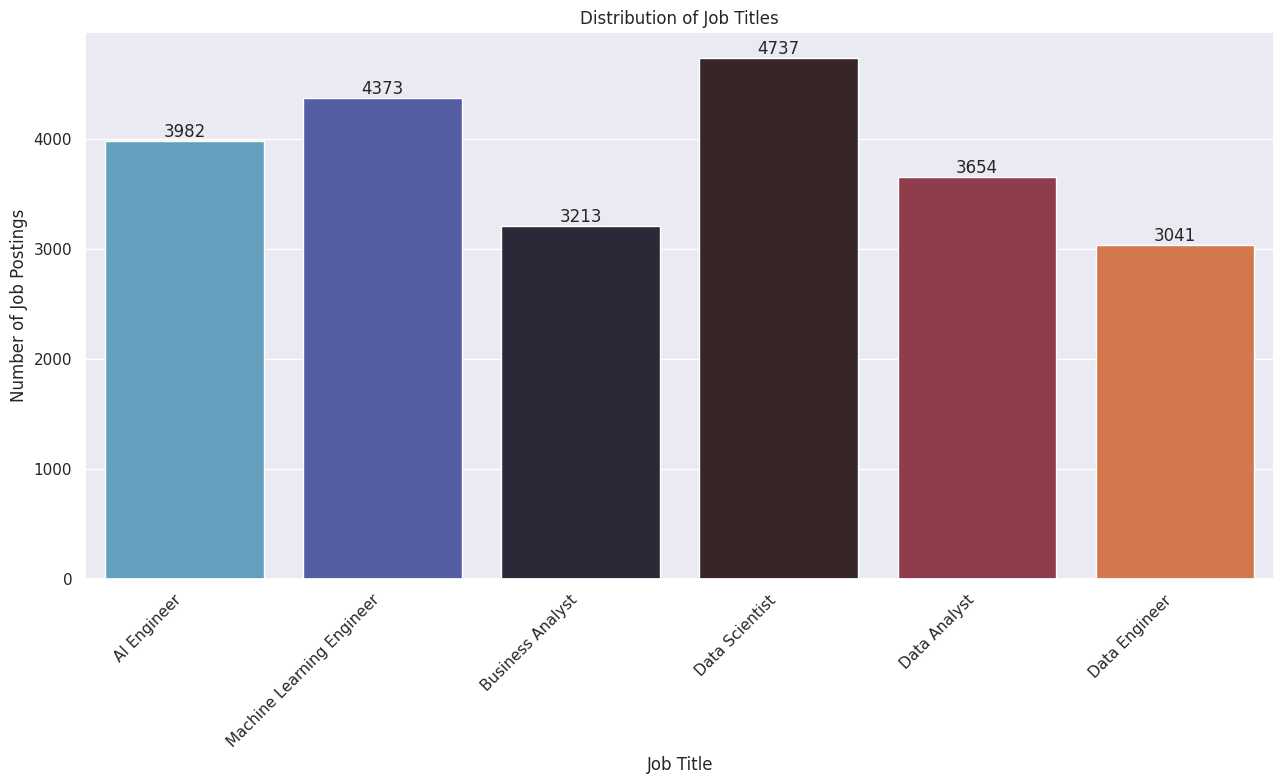

In [144]:
sns.set(rc={"figure.figsize":(13,8)})
l=sns.countplot(data=df, x="job_title", palette="icefire", hue="job_title", legend=False)
for i in l.containers:
  l.bar_label(i)
plt.title("Distribution of Job Titles")
plt.xlabel("Job Title")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [145]:
df["job_openings"]=df["job_openings"].astype("int64")
df["job_openings"].unique()

array([ 4,  9,  7,  2,  8,  3,  5,  6,  1,  0, 10])

In [146]:
r=df.groupby("job_title",as_index=False)["job_openings"].sum()
r

,job_title,job_openings
0,AI Engineer,18689
1,Business Analyst,15284
2,Data Analyst,17416
3,Data Engineer,14344
4,Data Scientist,22348
5,Machine Learning Engineer,20581


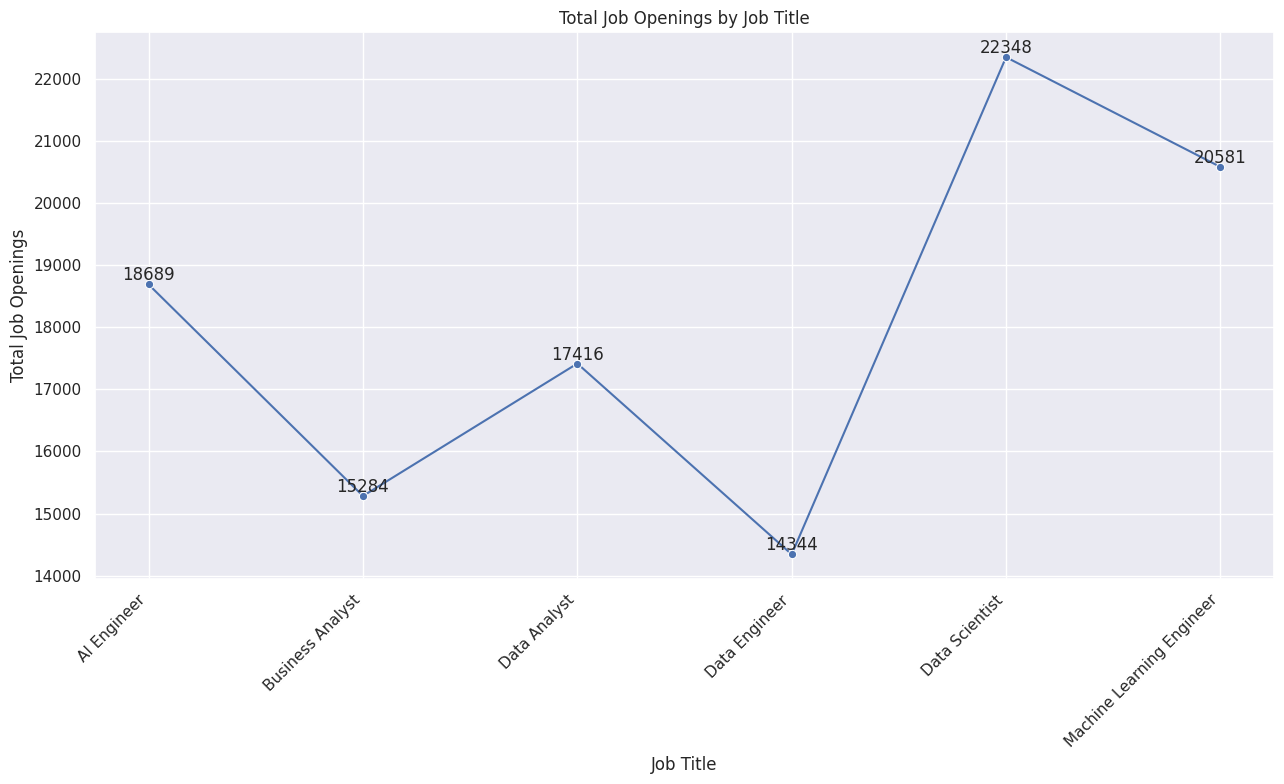

In [147]:
sns.lineplot(data=r,x="job_title",y="job_openings",marker="o")
plt.title("Total Job Openings by Job Title")
plt.xlabel("Job Title")
plt.ylabel("Total Job Openings")
plt.xticks(rotation=45, ha='right')
for x, y in zip(r["job_title"], r["job_openings"]):
    plt.text(x, y, f'{y:.0f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

**the most demanding job title in ai field is data scientist**

In [148]:
q1=df["salary"].quantile(0.25)
q3=df["salary"].quantile(0.75)
iqr=q3-q1
lower_bound=q1-(1.5*iqr)
upper_bound=q3+(1.5*iqr)
df_clean=df[(df["salary"]>=lower_bound) & (df["salary"]<=upper_bound)]

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'AI Engineer'),
  Text(1, 0, 'Machine Learning Engineer'),
  Text(2, 0, 'Business Analyst'),
  Text(3, 0, 'Data Scientist'),
  Text(4, 0, 'Data Analyst'),
  Text(5, 0, 'Data Engineer')])

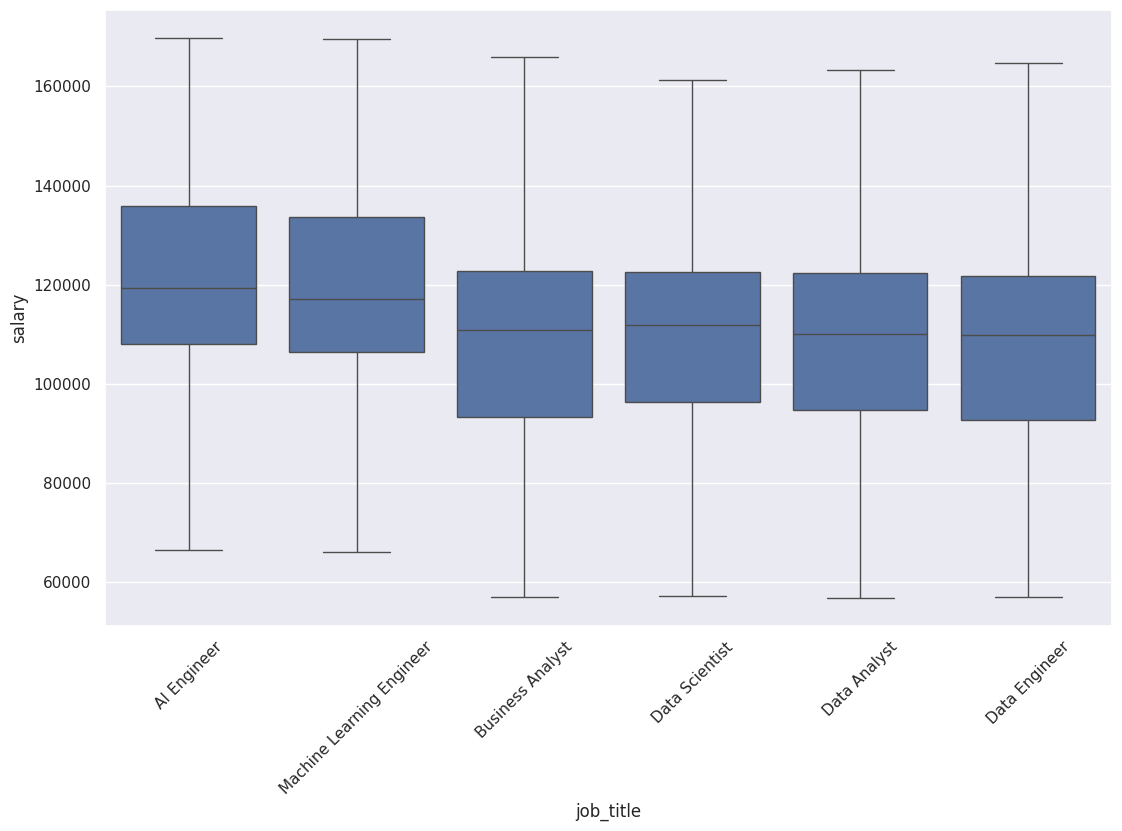

In [149]:
sns.boxplot(data=df_clean,x="job_title",y="salary",showfliers=False)
plt.xticks(rotation=45)

([<matplotlib.patches.Wedge at 0x7b67fc1f4680>,
 [Text(0.5358439232919505, 0.9606619019567135, 'Remote'),
  Text(-1.099663838604071, -0.027192684063183814, 'Hybrid'),
  Text(0.5594282982318792, -0.9471219452305937, 'Onsite')],
 [Text(0.29227850361379115, 0.5239974010672982, '33.80%'),
  Text(-0.5998166392385841, -0.014832373125372987, '33.18%'),
  Text(0.30514270812647953, -0.5166119701257783, '33.02%')])

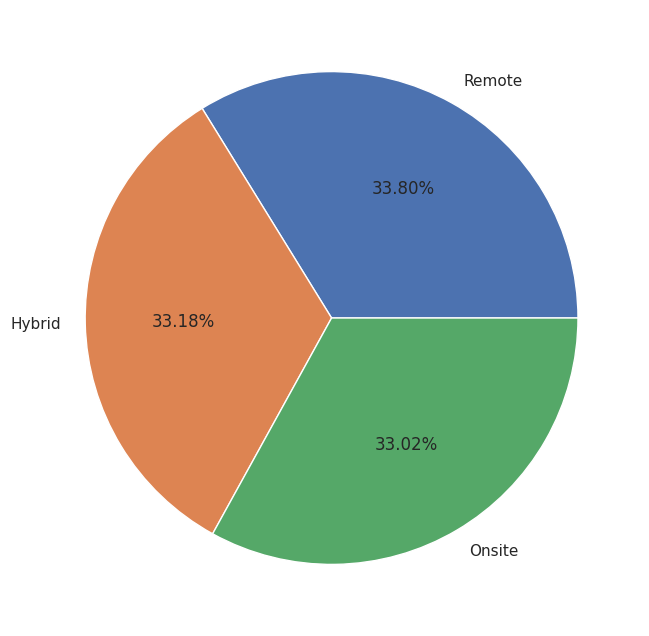

In [150]:
x=df["remote_type"].value_counts()
plt.pie(x.values,labels=x.index,autopct="%.2f%%")

([<matplotlib.patches.Wedge at 0x7b67fc365b80>,
 [Text(0.8914788058736449, 0.6444110013633383, 'skills_python'),
  Text(-0.33974539399887066, 1.046218460579124, 'skills_sql'),
  Text(-1.0998530895201115, -0.017977248762411087, 'skills_ml'),
  Text(-0.31050303064251955, -1.0552667283496673, 'skills_deep_learning'),
  Text(0.8988210073710374, -0.6341299525401034, 'skills_cloud')],
 [Text(0.48626116684016985, 0.3514969098345481, '19.92%'),
  Text(-0.18531566945392944, 0.5706646148613403, '20.15%'),
  Text(-0.5999198670109699, -0.00980577205222423, '20.38%'),
  Text(-0.1693652894413743, -0.575600033645273, '19.99%'),
  Text(0.4902660040205658, -0.34588906502187455, '19.56%')])

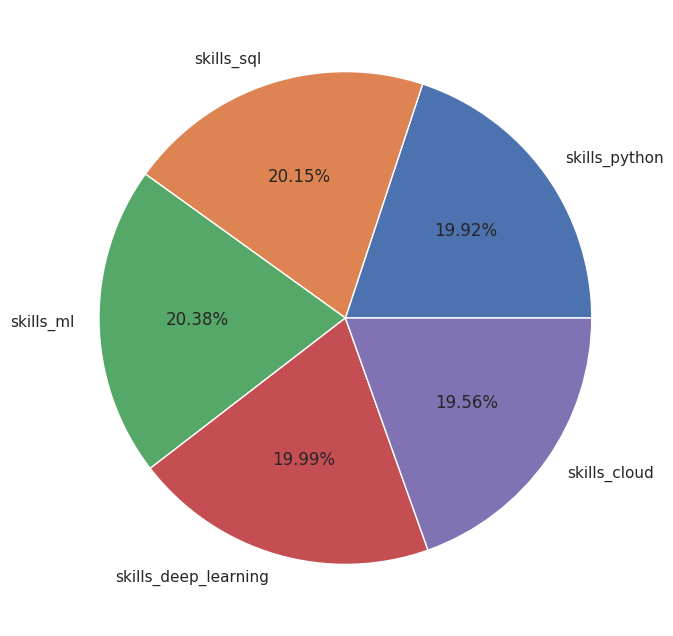

In [151]:
skills=["skills_python","skills_sql","skills_ml","skills_deep_learning","skills_cloud"]
skills_count=df[skills].sum()
plt.pie(skills_count.values,labels=skills_count.index,autopct="%.2f%%")

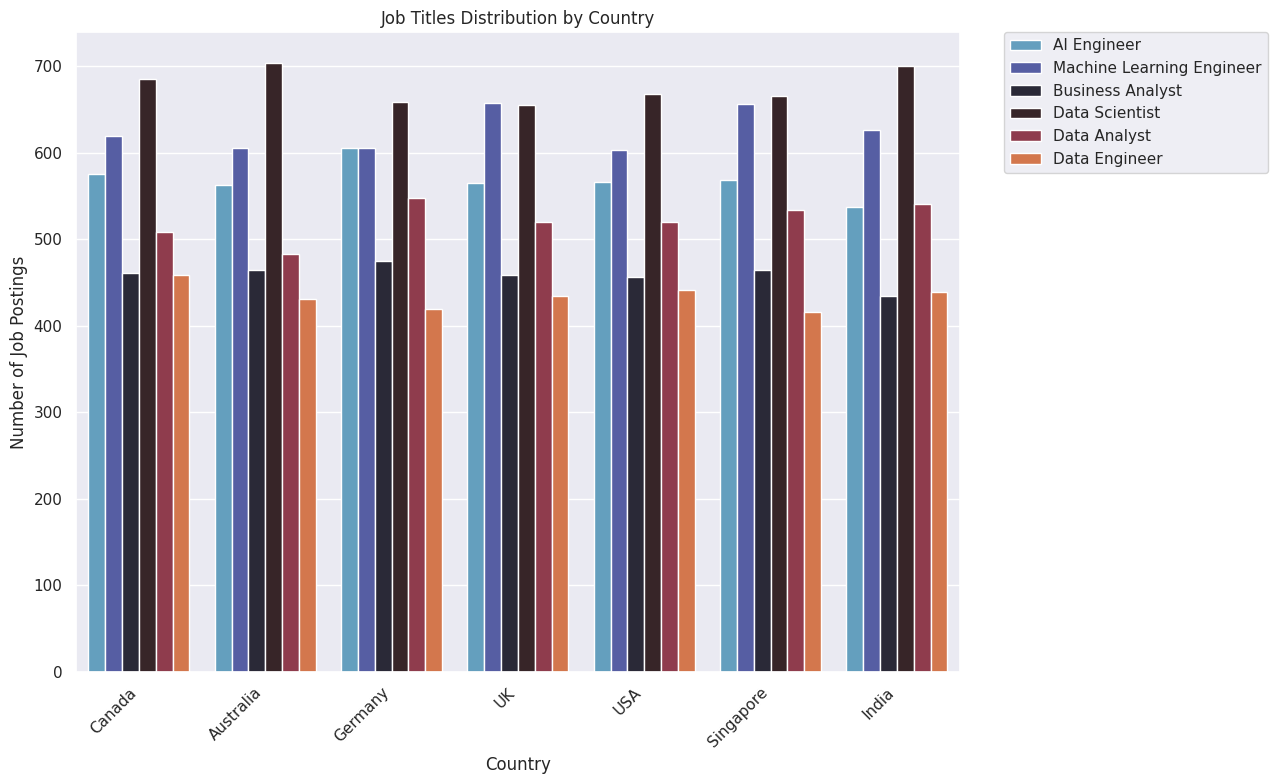

In [152]:
sns.countplot(data=df,x="country",hue="job_title",palette="icefire")
plt.title("Job Titles Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

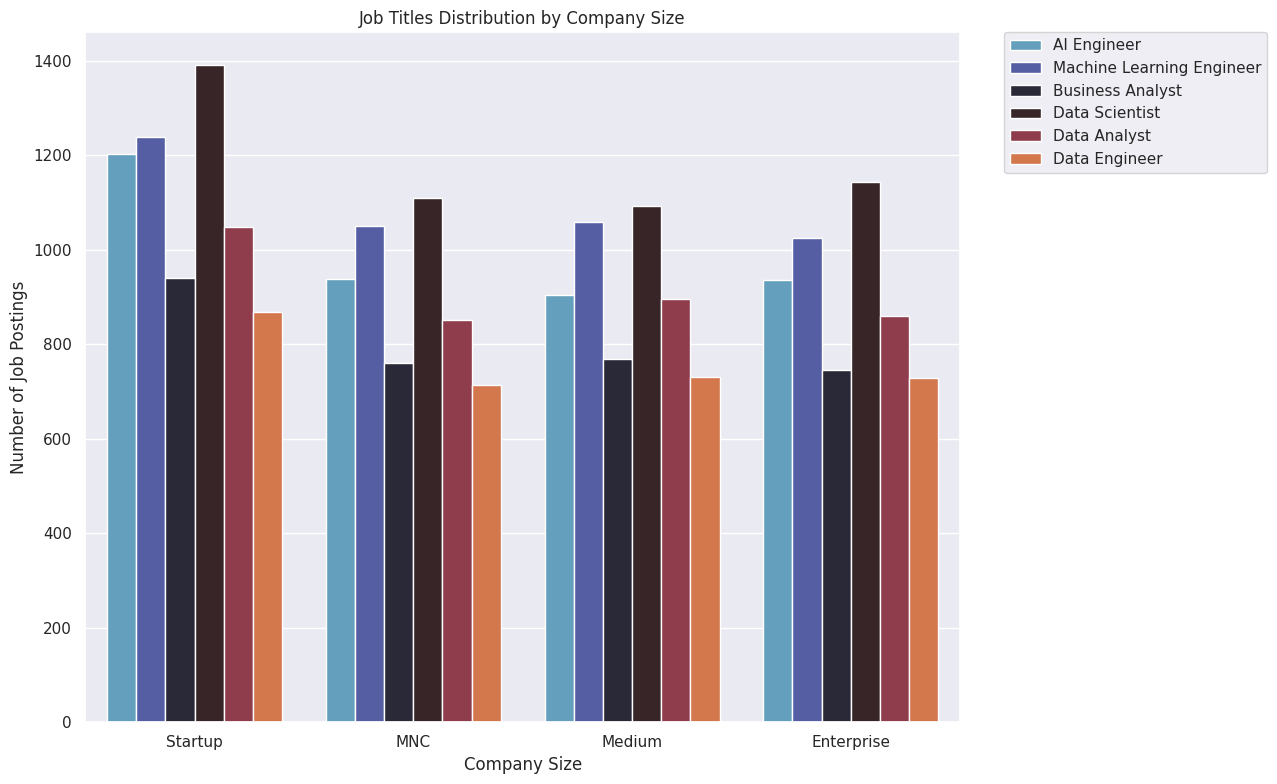

In [154]:
sns.countplot(data=df,x="company_size",hue="job_title",palette="icefire")
plt.title("Job Titles Distribution by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Number of Job Postings")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

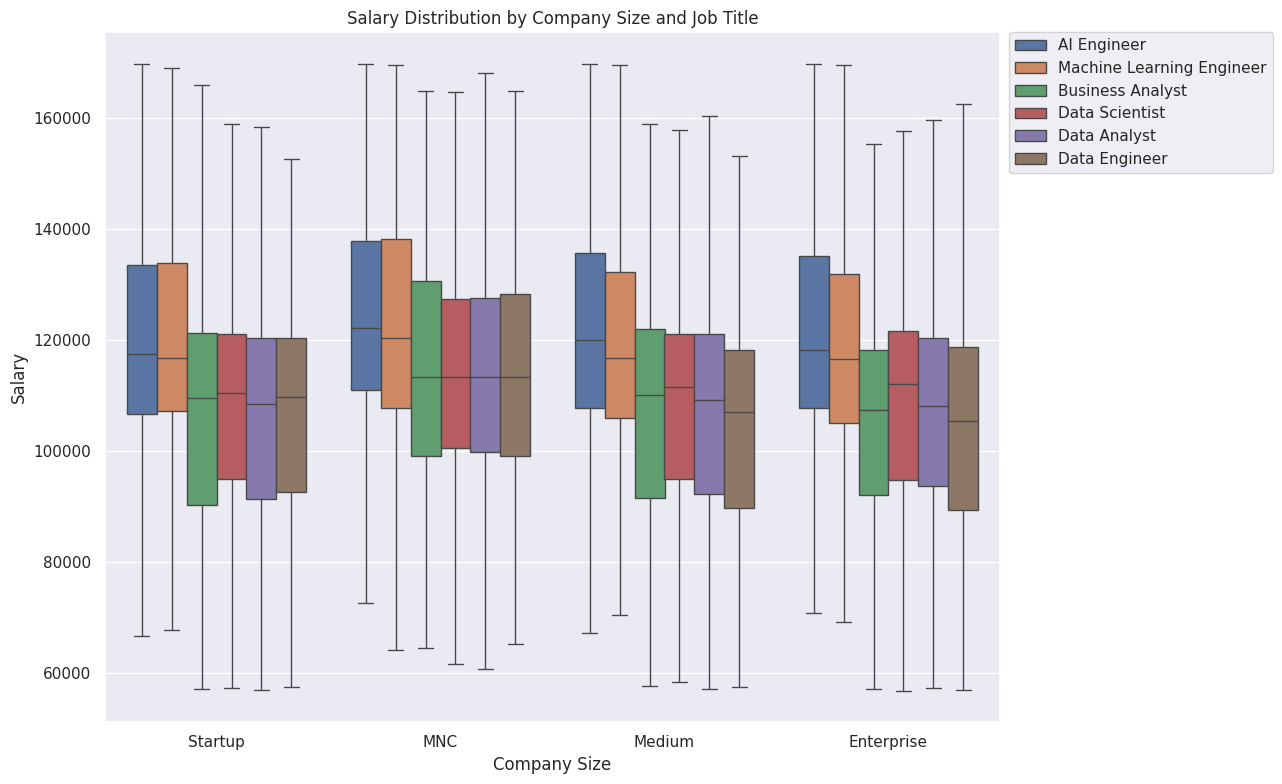

In [165]:
sns.boxplot(data=df_clean,x="company_size",y="salary",showfliers=False,hue="job_title")
plt.title("Salary Distribution by Company Size and Job Title")
plt.xlabel("Company Size")
plt.ylabel("Salary")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

In [177]:
e=df.groupby("company_size",as_index=False)["job_openings"].sum()
e

,company_size,job_openings
0,Enterprise,25780
1,MNC,25587
2,Medium,25829
3,Startup,31466


Text(0.5, 0, 'Company Size')

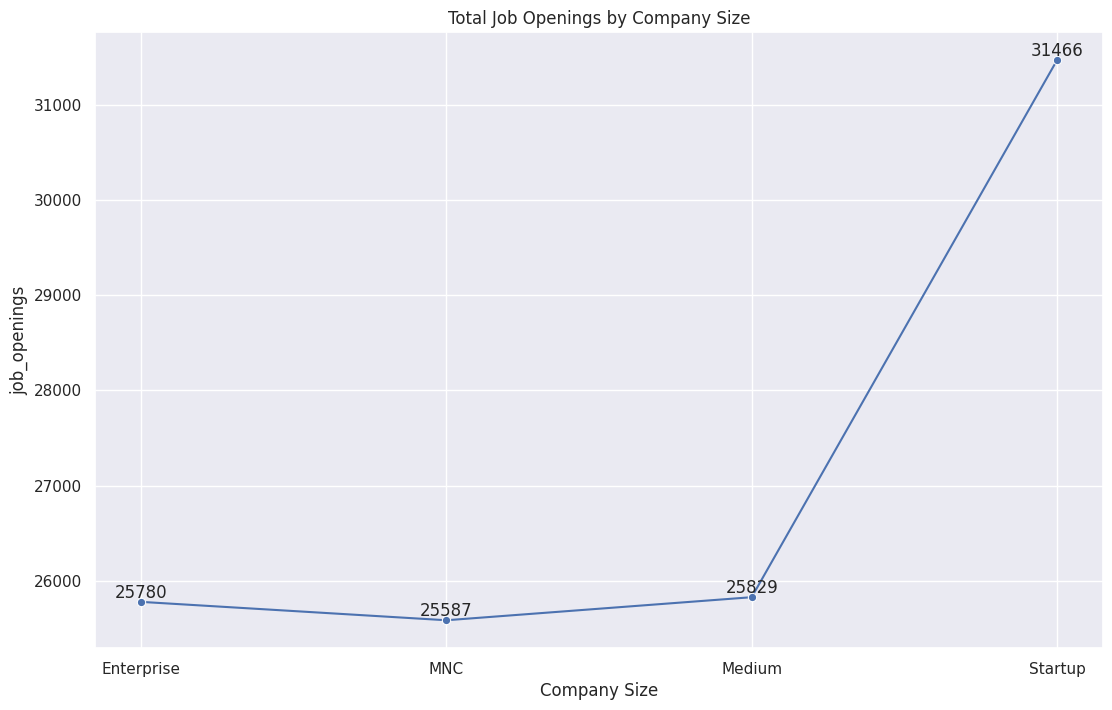

In [181]:
sns.lineplot(data=e,x="company_size",y="job_openings",marker="o")
for x,y in zip(e["company_size"],e["job_openings"]):
  plt.text(x,y,f'{y:.0f}',ha="center",va="bottom")
plt.title("Total Job Openings by Company Size")
plt.xlabel("Company Size")

<Axes: >

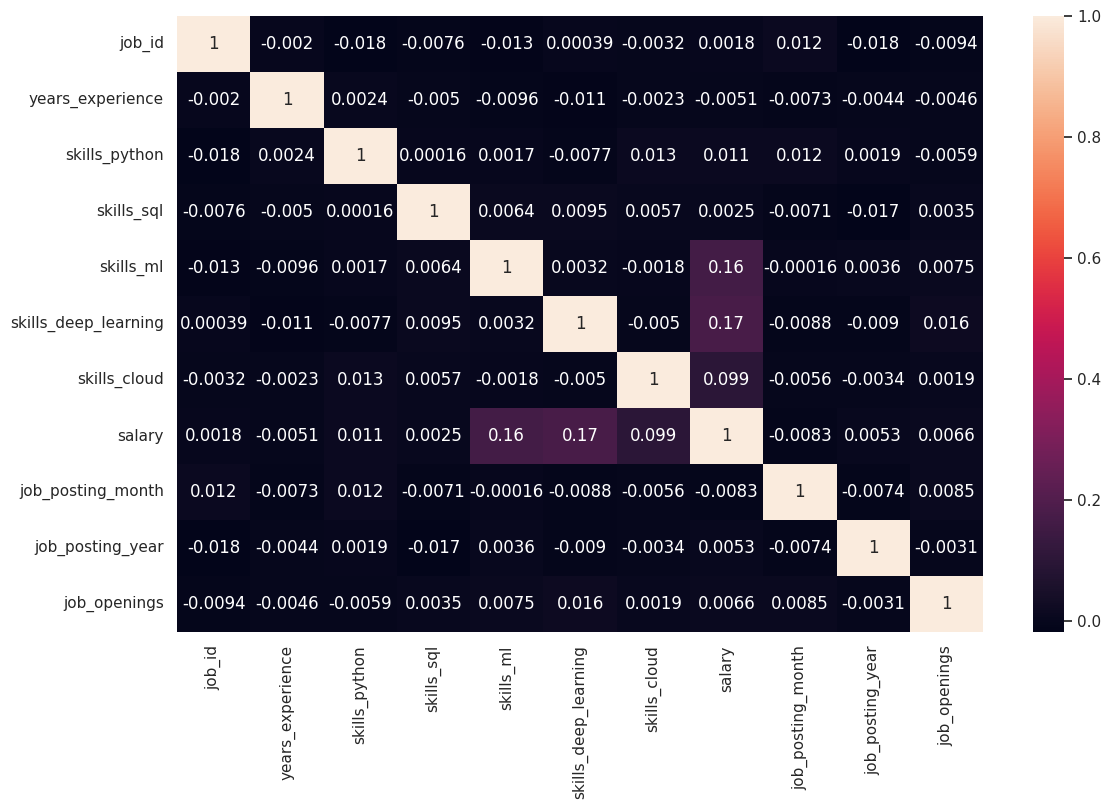

In [179]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

### Final Conclusion:

Based on the comprehensive analysis of the AI Job Market Dataset, here's a summary of our findings:

#### Key Findings from Data Analysis:

1.  **Most Demanding Job Titles**: 'Data Scientist' emerged as the most demanding job title with the highest number of total job openings (22,348), closely followed by 'Machine Learning Engineer' (20,581). This highlights the strong market demand for data-driven insights and AI model development roles.
2.  **Salary Trends**: While salaries vary across job titles, 'AI Engineer' and 'Machine Learning Engineer' generally command higher median salaries. The 'years_experience' shows a positive correlation with 'salary', indicating that more experienced professionals tend to earn more.
3.  **Remote Work Preference**: The distribution of remote, hybrid, and onsite job types is remarkably balanced, with each accounting for approximately one-third of the total job postings. This suggests flexibility in work arrangements is a significant aspect of the AI job market.
4.  **Essential Skills**: Skills like Python, SQL, Machine Learning (ML), Deep Learning (DL), and Cloud Computing are all crucial, showing a relatively even demand, with each skill being present in about 19-20% of job postings. This indicates a need for a well-rounded skill set in the AI domain.
5.  **Geographical Distribution**: The United States and Germany appear to be leading countries in terms of AI job opportunities across various titles.
6.  **Company Size Impact**: Startups lead in the total number of job openings (31,466), indicating a vibrant and growing sector for AI professionals in smaller, innovative companies. Medium-sized companies, Enterprise companies, and MNCs also offer a substantial number of opportunities.

#### Overall Summary:

The AI job market is robust and dynamic, with a high demand for skilled professionals, particularly Data Scientists and Machine Learning Engineers. While experience significantly influences salary, a diverse skill set encompassing Python, SQL, ML, DL, and cloud technologies is essential. The market also offers considerable flexibility in work arrangements across different company sizes, with startups being a major source of new opportunities. This analysis provides valuable insights for job seekers and companies looking to navigate the competitive AI talent landscape.